In [1]:
#!conda env list

In [2]:
#!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# Cell 1: Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# Allow OGR to accept non-closed rings
os.environ["OGR_GEOMETRY_ACCEPT_UNCLOSED_RING"] = "YES"

# --- Configuration ---
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"  # UTM Zone 15
tornado_csv = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_EET_bins.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]
min_date = pd.to_datetime("1950-01-01")  # Start from first date in dataset

In [5]:
# Cell 2: Load UMESC Mississippi River shapefiles
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]
gdfs = []

for pool_dir in pool_dirs:
    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        local_crs = "EPSG:26916"
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        local_crs = target_crs

    for f in shp_files:
        gdf = gpd.read_file(f)
        if gdf.crs is None:
            gdf = gdf.set_crs(local_crs)
        gdf = gdf.to_crs(target_crs)
        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)
print("UMESC combined:", umesc_all.shape)
print(f"Pools included: {sorted(umesc_all['POOL'].unique())}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/njm12/ATMS_523/envs/xarray-climate/share/proj failed


UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']


In [6]:
# --- Derive approximate river centerline from UMESC polygons ---
# Fix invalid polygons before union
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)  # Ensures clean geometry

# Use the new 'union_all()' method (replaces deprecated unary_union)
river_union = umesc_all.union_all()

# Derive approximate river centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)
print("River centerline constructed from UMESC polygons.")

River centerline constructed from UMESC polygons.


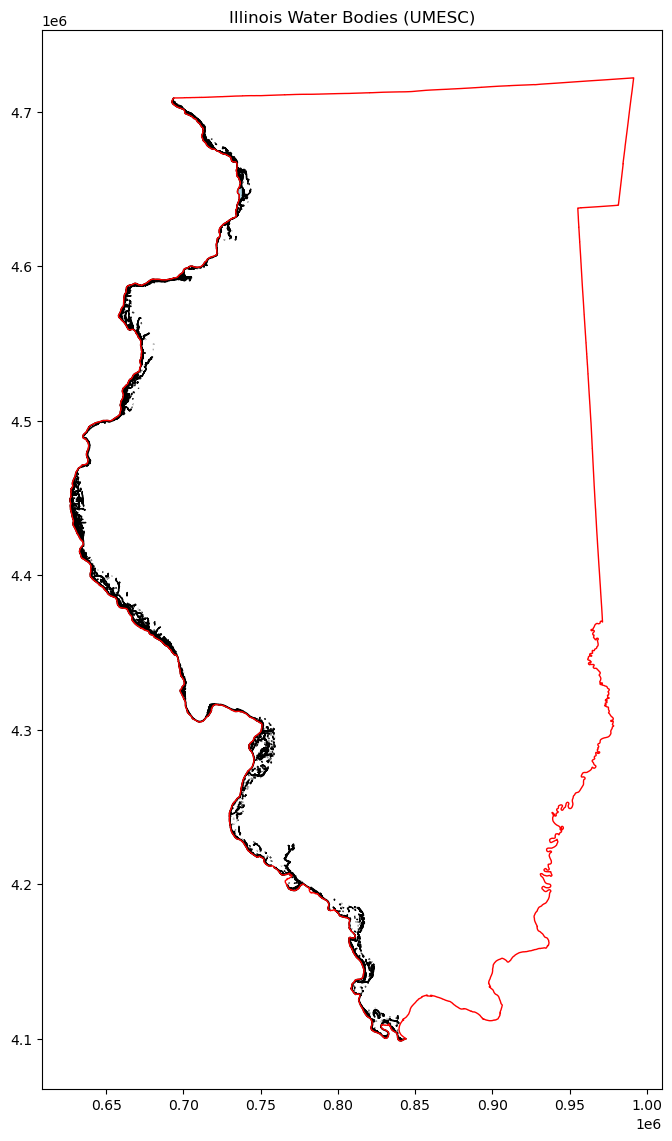

In [7]:
# Cell 3: Extract Illinois water portion
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)
illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

# Filter water polygons only
water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()
water_il = gpd.clip(water_only, illinois)

# Plot check
ax = water_il.plot(figsize=(8, 14), color="lightblue", edgecolor="k")
illinois.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Illinois Water Bodies (UMESC)")
plt.show()

In [8]:
print("Number of invalid geometries in water_only:", (~water_only.is_valid).sum())
print("Invalid geometries indices:", water_only[~water_only.is_valid].index)

Number of invalid geometries in water_only: 0
Invalid geometries indices: Index([], dtype='int64')


In [9]:
# Fix invalid geometries using buffer(0) - only if needed
water_only.loc[~water_only.is_valid, "geometry"] = water_only.loc[~water_only.is_valid, "geometry"].buffer(0)

# Verify
print("Invalid geometries after fix:", (~water_only.is_valid).sum())

Invalid geometries after fix: 0


In [10]:
# Ensure Illinois geometry is valid
illinois["geometry"] = illinois["geometry"].buffer(0)

# Perform clip
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

Clipped water shapes: (2876, 14)


In [11]:
# Combine all Illinois water polygons into a single geometry
river_il = water_il.union_all()
print(type(river_il))
print("Bounds of Illinois river section:", river_il.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Bounds of Illinois river section: (626594.3664122473, 4098437.22724262, 844182.0029604747, 4708927.272888837)


In [12]:
# Automatic date parsing
tornadoes = pd.read_csv(tornado_csv, parse_dates=['date'])

# Filter by states, pre-F/F/EF-scale, and date (can include stronger tornadoes on map, if necessary / min_date will likely be changed)
tornadoes = tornadoes[
    tornadoes['st'].isin(states_of_interest) &
    tornadoes['mag'].isin([0, 1, 2, 3, 4, 5]) &
    (tornadoes['date'] >= min_date)
]

print("Filtered tornadoes:", tornadoes.shape)
tornadoes

Filtered tornadoes: (8287, 34)


,om,yr,mo,dy,date,time,tz,st,stf,stn,...,f1,f2,f3,f4,fc,datetime,sunrise_local,sunset_local,day_night_bin,nocturnal_bin
0,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,119,117,0,0,0,1950-12-02 15:00:00-06:00,1950-12-02 07:00:56.487661-06:00,1950-12-02 16:38:03.787114-06:00,Day,Day
1,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,119,5,0,0,0,1950-12-02 16:00:00-06:00,1950-12-02 06:58:49.244195-06:00,1950-12-02 16:37:08.674669-06:00,Day,Day
2,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,157,0,0,0,0,1950-12-02 17:30:00-06:00,1950-12-02 06:57:41.974386-06:00,1950-12-02 16:39:09.003928-06:00,Night,Early Evening Transition
3,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,93,0,0,0,0,1950-01-25 19:30:00-06:00,1950-01-25 07:12:19.167490-06:00,1950-01-25 17:18:20.206660-06:00,Night,Post-Transition
4,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,91,0,0,0,0,1950-01-25 21:00:00-06:00,1950-01-25 07:07:14.812744-06:00,1950-01-25 16:56:38.836911-06:00,Night,Post-Transition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8282,624857,2024,8,15,2024-08-15,22:06:00,3,IL,17,0,...,175,0,0,0,0,2024-08-15 22:06:00-05:00,2024-08-15 06:10:28.647548-05:00,2024-08-15 19:57:22.068989-05:00,Night,Post-Transition
8283,624880,2024,8,30,2024-08-30,11:45:00,3,IL,17,0,...,157,0,0,0,0,2024-08-30 11:45:00-05:00,2024-08-30 06:28:19.260504-05:00,2024-08-30 19:30:38.696436-05:00,Day,Day
8284,624820,2024,8,5,2024-08-05,20:57:00,3,IA,19,0,...,191,0,0,0,0,2024-08-05 20:57:00-05:00,2024-08-05 06:02:36.842388-05:00,2024-08-05 20:23:41.746723-05:00,Night,Early Evening Transition
8285,624821,2024,8,5,2024-08-05,21:11:00,3,IA,19,0,...,191,0,0,0,0,2024-08-05 21:11:00-05:00,2024-08-05 06:02:07.597288-05:00,2024-08-05 20:23:11.960360-05:00,Night,Early Evening Transition


In [13]:
print("Columns in dataset:")
print(tornadoes.columns)

print("\nPreliminary Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())

Columns in dataset:
Index(['om', 'yr', 'mo', 'dy', 'date', 'time', 'tz', 'st', 'stf', 'stn', 'mag',
       'inj', 'fat', 'loss', 'closs', 'slat', 'slon', 'elat', 'elon', 'len',
       'wid', 'ns', 'sn', 'sg', 'f1', 'f2', 'f3', 'f4', 'fc', 'datetime',
       'sunrise_local', 'sunset_local', 'day_night_bin', 'nocturnal_bin'],
      dtype='object')

Preliminary Day/Night counts:
day_night_bin
Day      6155
Night    2132
Name: count, dtype: int64


In [14]:
# Remove any rows with missing or invalid coordinates
coord_cols = ['slon', 'slat', 'elon', 'elat']
tornadoes = tornadoes.dropna(subset=coord_cols)

# Remove out-of-bounds or unrealistic coordinates
tornadoes = tornadoes[
    (tornadoes['slon'].between(-180, 180)) &
    (tornadoes['elon'].between(-180, 180)) &
    (tornadoes['slat'].between(-90, 90)) &
    (tornadoes['elat'].between(-90, 90))
]
print("After coordinate cleaning:", tornadoes.shape)

After coordinate cleaning: (8287, 34)


In [15]:
# --- Fix 1: Convert positive longitudes (U.S. longitudes are negative west of Greenwich) ---
tornadoes['slon'] = tornadoes['slon'].apply(lambda x: -x if x > 0 else x)
tornadoes['elon'] = tornadoes['elon'].apply(lambda x: -x if x > 0 else x)

# --- Fix 2: Remove zero or missing coordinates (invalid positions) ---
tornadoes.loc[tornadoes['slat'] == 0, 'slat'] = np.nan
tornadoes.loc[tornadoes['elat'] == 0, 'elat'] = np.nan
tornadoes.loc[tornadoes['slon'] == 0, 'slon'] = np.nan
tornadoes.loc[tornadoes['elon'] == 0, 'elon'] = np.nan

# Drop rows with NaNs after cleaning
tornadoes = tornadoes.dropna(subset=['slon', 'slat', 'elon', 'elat']).copy()

# Check coordinate ranges again
print("Longitude range (fixed):", tornadoes[['slon', 'elon']].min().min(), "to", tornadoes[['slon', 'elon']].max().max())
print("Latitude range (fixed):", tornadoes[['slat', 'elat']].min().min(), "to", tornadoes[['slat', 'elat']].max().max())

Longitude range (fixed): -96.6 to -85.23
Latitude range (fixed): 36.0022 to 45.5


In [16]:
from shapely.geometry import LineString, Point
import geopandas as gpd

# Create LineString or Point geometries
def make_geom(row):
    if pd.isna(row['elon']) or pd.isna(row['elat']) or \
       (row['elon'] == row['slon'] and row['elat'] == row['slat']):
        return Point(row['slon'], row['slat'])
    else:
        return LineString([(row['slon'], row['slat']), (row['elon'], row['elat'])])

tornadoes['geometry'] = tornadoes.apply(make_geom, axis=1)

# Convert to GeoDataFrame
tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry='geometry', crs="EPSG:4326")

# Reproject to match water shapefile CRS
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado geometries rebuilt")
print("Geometry types:", tornado_gdf.geometry.geom_type.value_counts())
print("Bounds:", tornado_gdf.total_bounds)

Tornado geometries rebuilt
Geometry types: LineString    4739
Point         1054
Name: count, dtype: int64
Bounds: [ 205367.62901075 3987738.95756939 1160467.39964418 5041734.47457036]


In [17]:
# Fix invalid water polygons
water_il['geometry'] = water_il['geometry'].buffer(0)

# Merge into single geometry
river_il_geom = water_il.geometry.union_all()  # or .union_all() if using new shapely

# Ensure the final geometry is valid
from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

In [18]:
# Buffer by 10 km
river_buffer = river_il_geom.buffer(10000)  # adjust as needed

# Check intersections with buffer
tornado_gdf['crosses_river'] = tornado_gdf.intersects(river_buffer)
crossings = tornado_gdf[tornado_gdf['crosses_river']]

print("Total tornadoes crossing Mississippi River or intersecting buffered zone:", crossings.shape[0])
print("Counts by pre-F/F/EF-scale:\n", crossings['mag'].value_counts())

Total tornadoes crossing Mississippi River or intersecting buffered zone: 372
Counts by pre-F/F/EF-scale:
 mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [19]:
#Quick sanity check to make sure the river buffer is actually or approximately ~10 km (and in the right units). 

from shapely.ops import nearest_points

# Pick a point on the river geometry
river_point = river_il_geom.representative_point()

# Pick nearest point on the buffer boundary
buffer_boundary = river_buffer.boundary
nearest = nearest_points(river_point, buffer_boundary)[1]

# Compute distance in meters (UTM units)
distance_m = river_point.distance(nearest)
distance_km = distance_m / 1000
print(f"Distance from river to buffer boundary: {distance_km:.2f} km")

Distance from river to buffer boundary: 10.67 km


In [20]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# # --- Step 5: Plot ---
# fig, ax = plt.subplots(figsize=(10, 14))

# # Plot Illinois water and river buffer
# water_il.plot(ax=ax, color='lightblue', edgecolor='k')
# gpd.GeoSeries([river_buffer]).boundary.plot(ax=ax, color='red', linewidth=2, label='10 km Buffer')

# # Plot all tornadoes (lines + points)
# tornado_gdf.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3)
# tornado_gdf[tornado_gdf.geometry.geom_type == 'Point'].plot(ax=ax, color='gray', markersize=15, alpha=0.4)

# # Plot crossing tornadoes (lines + points)
# crossings.plot(ax=ax, color='blue', linewidth=1.5)
# crossings[crossings.geometry.geom_type == 'Point'].plot(ax=ax, color='blue', markersize=25)

# # Plot Illinois, Missouri, and Iowa boundaries
# illinois.boundary.plot(ax=ax, color='black', linewidth=1, label='Illinois Boundary')

# states_path = "/home/njm12/ATMS_596/ne_10m_admin_1_states_provinces.shp"
# states = gpd.read_file(states_path).to_crs(target_crs)
# states_mo_ia = states[states['name'].isin(['Missouri', 'Iowa'])]
# states_mo_ia.boundary.plot(ax=ax, color='lightgray', linewidth=1, label='MO / IA Boundary')

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # --- Labels, title, and caption ---
# ax.legend(handles=legend_elements, loc='upper right')
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.set_xlabel("Easting (meters, UTM Zone 15N)", fontsize=11)
# ax.set_ylabel("Northing (meters, UTM Zone 15N)", fontsize=11)

# # Figure caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in UTM Zone 15N (meters)."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

# plt.show()

In [21]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # Reproject all layers to geographic (EPSG:4326)
# tornado_geo = tornado_gdf.to_crs("EPSG:4326")
# crossings_geo = crossings.to_crs("EPSG:4326")
# water_il_geo = water_il.to_crs("EPSG:4326")
# illinois_geo = illinois.to_crs("EPSG:4326")
# river_buffer_geo = gpd.GeoSeries([river_buffer], crs=water_il.crs).to_crs("EPSG:4326")

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# # Add map background
# ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
# ax.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.6)

# # Plot layers
# water_il_geo.plot(ax=ax, color='lightblue', edgecolor='k', transform=ccrs.PlateCarree(), zorder=1)
# river_buffer_geo.boundary.plot(ax=ax, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), label='10 km Buffer', zorder=2)
# tornado_geo.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3, transform=ccrs.PlateCarree(), label='All Tornadoes', zorder=3)
# crossings_geo.plot(ax=ax, color='blue', linewidth=1.5, transform=ccrs.PlateCarree(), label='Crossing Tornadoes', zorder=4)
# illinois_geo.boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

# # Gridlines and coordinate labels
# gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlabel_style = {'size': 11}
# gl.ylabel_style = {'size': 11}

# # Add axis labels manually
# ax.text(0.5, -0.06, 'Longitude (°W)', va='center', ha='center', fontsize=12, transform=ax.transAxes)
# ax.text(-0.08, 0.5, 'Latitude (°N)', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

# # --- Custom legend handles (combined line + point) ---
# legend_elements = [
#     Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
#            label='All Tornadoes', alpha=0.6),
#     Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
#            label='Crossing Tornadoes', alpha=0.9),
#     Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
#     Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
#     Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
# ]

# # Add title and legend
# ax.set_title("All Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
# ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# # Caption
# caption = (
#     "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
#     "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
#     "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
#     "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
#     "provide geographic context. Coordinates are shown in degrees latitude and longitude."
# )
# plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

In [22]:
# -------------------------------------------------------------------
# --- Identify west-side, east-side, and crossing tornadoes ---
# UPDATED: NEAREST-POINT RIVER METHOD
# -------------------------------------------------------------------

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Start with all tornadoes (EF0–EF5)
# ------------------------------------------------
weak_tornadoes = tornado_gdf[
    tornado_gdf["mag"].isin([0, 1, 2, 3, 4, 5])
].copy()

# ------------------------------------------------
# 2. Tornadoes that physically cross/touch river
# (UNCHANGED)
# ------------------------------------------------
crossing_tornadoes = weak_tornadoes[
    weak_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Tornadoes within/touching 10 km buffer
# but NOT touching/crossing river
# ------------------------------------------------
buffer_only = weak_tornadoes[
    weak_tornadoes.intersects(river_buffer) &
    (~weak_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Representative point for side determination
# ------------------------------------------------
buffer_only["rep_point"] = (
    buffer_only.geometry.representative_point()
)

# ------------------------------------------------
# 5. Determine west/east relative to
# LOCAL NEAREST RIVER POSITION
# ------------------------------------------------
def assign_side(point_geom):

    # nearest point ON river
    nearest_river_pt = nearest_points(
        point_geom,
        river_il_geom
    )[1]

    # compare relative x-position
    dx = point_geom.x - nearest_river_pt.x

    return "West" if dx < 0 else "East"

# Apply classification
buffer_only["side"] = (
    buffer_only["rep_point"]
    .apply(assign_side)
)

# ------------------------------------------------
# 6. Final west/east groups
# ------------------------------------------------
west_side = buffer_only[
    buffer_only["side"] == "West"
].copy()

east_side = buffer_only[
    buffer_only["side"] == "East"
].copy()

# ------------------------------------------------
# 7. Print summary results
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")

print(f"Total tornadoes: {len(weak_tornadoes)}")

print(
    "  • West-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(west_side)}"
)

print(
    "  • East-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(east_side)}"
)

print(
    "  • Crossing/touching the river: "
    f"{len(crossing_tornadoes)}"
)

print(
    "  • Sum check: "
    f"{len(west_side) + len(east_side) + len(crossing_tornadoes)} "
    "(should equal 372)"
)


--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side (within/touching 10 km buffer, not touching river): 142
  • East-side (within/touching 10 km buffer, not touching river): 141
  • Crossing/touching the river: 89
  • Sum check: 372 (should equal 372)


In [23]:
# ---------- Robust classification into West Control / East Control / Test (buffer/river) ----------
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure we use the variable names you have defined earlier:
# tornado_gdf  (all tornadoes, already reprojected to target_crs)
# weak_tornadoes (subset of tornado_gdf with mag in [0,1,2])
# river_il_geom  (shapely geometry of Illinois river section)
# river_buffer   (10 km buffer around river_il_geom) -- can be shapely geometry or GeoSeries

# 0) Ensure consistent CRS on weak_tornadoes
weak_tornadoes = weak_tornadoes.to_crs(target_crs)

# 1) Ensure buffer is a single (unary) shapely geometry for intersections
# If river_buffer is a GeoSeries or GeoDataFrame, get the unary_union (or .iloc[0] if single)
try:
    buffer_union = river_buffer
    # if it's a GeoSeries/GeoDataFrame convert to unary_union
    if hasattr(buffer_union, "unary_union"):
        buffer_union = buffer_union.unary_union
except NameError:
    # If river_buffer not available, create from river_il_geom
    buffer_union = river_il_geom.buffer(10000).union()

In [24]:
# 2) Test population: any weak tornado that intersects/touches the buffer OR intersects the river polygon itself
#    (this includes crossings which intersect the river geometry)
test_mask = weak_tornadoes.geometry.intersects(buffer_union) | weak_tornadoes.geometry.intersects(river_il_geom)
test_population = weak_tornadoes[test_mask].copy()

In [25]:
# 3) Outside buffer: those that do NOT intersect the buffer
# Compute side relative to actual river geometry
outside_buffer = weak_tornadoes[~test_mask].copy()

outside_buffer["centroid"] = outside_buffer.geometry.centroid

def assign_west_east(row, river_geom):
    centroid = row.centroid
    nearest = nearest_points(centroid, river_geom)[1]  # nearest point on river
    dx = centroid.x - nearest.x
    return "West Control" if dx < 0 else "East Control"

outside_buffer["side_type"] = outside_buffer.apply(assign_west_east, axis=1, river_geom=river_il_geom)

# Reassign west_control and east_control
west_control = outside_buffer[outside_buffer["side_type"] == "West Control"].copy()
east_control = outside_buffer[outside_buffer["side_type"] == "East Control"].copy()

#Before: split by centroid_x vs a single river_center_x -> vertical line.
#After: split by relative position to nearest river point -> follows meandering river.

In [26]:
# 7) Verify counts and find any unclassified (should not happen, but check)
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("Initial sizes:")
print(f"  Test population (intersect buffer/river): {len(test_population)}")
print(f"  West control (outside buffer):            {len(west_control)}")
print(f"  East control (outside buffer):            {len(east_control)}")
print(f"  Unclassified (should be 0):               {len(unclassified)}")
print(f"  Sum categories:                           {len(test_population)+len(west_control)+len(east_control)}")
print(f"  Total tornadoes:                          {len(weak_tornadoes)}")

Initial sizes:
  Test population (intersect buffer/river): 372
  West control (outside buffer):            3554
  East control (outside buffer):            1867
  Unclassified (should be 0):               0
  Sum categories:                           5793
  Total tornadoes:                          5793


In [27]:
print("\nUpdated Day/Night counts:")
print(tornadoes["day_night_bin"].value_counts())


Updated Day/Night counts:
day_night_bin
Day      4303
Night    1490
Name: count, dtype: int64


In [28]:
# 8) If any unclassified exist (tiny rounding artifacts), assign them deterministically:
if len(unclassified) > 0:
    # compute centroid x for those too
    unclassified["centroid"] = unclassified.geometry.centroid
    unclassified["centroid_x"] = unclassified["centroid"].apply(lambda p: p.x)
    # assign by centroid_x
    assign_west = unclassified[unclassified["centroid_x"] < river_center_x].index
    assign_east = unclassified[unclassified["centroid_x"] >= river_center_x].index
    west_control = pd.concat([west_control, unclassified.loc[assign_west]])
    east_control = pd.concat([east_control, unclassified.loc[assign_east]])
    # recompute combined check
    combined_idx = test_population.index.union(west_control.index).union(east_control.index)
    unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
    print("After deterministic centroid assignment, remaining unclassified:", len(unclassified))
    # If still unclassified (very unlikely), assign by nearest distance to river centerline
    if len(unclassified) > 0:
        # build a river centerline (if you have river_centerline GeoSeries earlier use that)
        try:
            centerline = river_centerline.unary_union
        except Exception:
            # fallback: approximate centerline by taking river_il_geom.representative_point()
            centerline = river_il_geom.representative_point()
        # compute distance to centerline and assign west/east by centroid_x anyway
        for idx, row in unclassified.iterrows():
            cx = row.geometry.centroid.x
            if cx < river_center_x:
                west_control = pd.concat([west_control, row.to_frame().T])
            else:
                east_control = pd.concat([east_control, row.to_frame().T])
        
# final check
combined_idx = test_population.index.union(west_control.index).union(east_control.index)
unclassified = weak_tornadoes[~weak_tornadoes.index.isin(combined_idx)].copy()
print("After fallback nearest assignment, remaining unclassified:", len(unclassified))

After fallback nearest assignment, remaining unclassified: 0


In [29]:
# 9) Final assert / sanity check
total_calc = len(test_population) + len(west_control) + len(east_control)
print("\nFinal totals check:")
print(f"  Sum categories = {total_calc}")
print(f"  Total tornadoes = {len(weak_tornadoes)}")
assert total_calc == len(weak_tornadoes), "Final counts DO NOT sum to total tornadoes!"


Final totals check:
  Sum categories = 5793
  Total tornadoes = 5793


In [30]:
# 10) Create breakdown table for EF 0/1/2/3/4/5
def mag_counts(df):
    # Ensure mag is int-like and EF 0/1/2/3/4/5
    s = df["mag"].astype(int).value_counts().reindex([0, 1, 2, 3, 4, 5], fill_value=0)
    return s.to_dict()

summary = pd.DataFrame({
    "Category": ["West Control", "East Control", "Test (Buffer/River)"],
    "Count": [len(west_control), len(east_control), len(test_population)],
    "EF0": [mag_counts(west_control)[0], mag_counts(east_control)[0], mag_counts(test_population)[0]],
    "EF1": [mag_counts(west_control)[1], mag_counts(east_control)[1], mag_counts(test_population)[1]],
    "EF2": [mag_counts(west_control)[2], mag_counts(east_control)[2], mag_counts(test_population)[2]],
    "EF3": [mag_counts(west_control)[3], mag_counts(east_control)[3], mag_counts(test_population)[3]],
    "EF4": [mag_counts(west_control)[4], mag_counts(east_control)[4], mag_counts(test_population)[4]],
    "EF5": [mag_counts(west_control)[5], mag_counts(east_control)[5], mag_counts(test_population)[5]],
})

summary["Total EF0–EF5"] = summary[["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]].sum(axis=1)

# Add totals row
totals = summary[["Count", "EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "Total EF0–EF5"]].sum()
totals_row = pd.DataFrame([["All Tornadoes", totals["Count"], int(totals["EF0"]), int(totals["EF1"]), int(totals["EF2"]), int(totals["EF3"]), int(totals["EF4"]), int(totals["EF5"]), int(totals["Total EF0–EF5"])]],
                          columns=summary.columns)
summary = pd.concat([summary, totals_row], ignore_index=True)

print("\n--- Tornado Populations Summary ---")
print(summary.to_string(index=False))


--- Tornado Populations Summary ---
           Category  Count  EF0  EF1  EF2  EF3  EF4  EF5  Total EF0–EF5
       West Control   3554 1561 1158  588  176   65    6           3554
       East Control   1867  885  628  242   84   26    2           1867
Test (Buffer/River)    372  124  122   79   37   10    0            372
      All Tornadoes   5793 2570 1908  909  297  101    8           5793


In [31]:
# # ================================================================
# # Clustered Bar Chart: pre-F/F/EF-scale Distribution by Category
# # ================================================================

# import numpy as np
# import matplotlib.pyplot as plt

# # Categories (clusters)
# categories = ["West Control", "East Control", "Test (Buffer/River)"]

# # pre-F/F/EF-scale bins
# ef_bins = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]

# # Extract counts from summary table
# data = summary.loc[summary["Category"].isin(categories), ef_bins].values

# # Bar configuration
# n_groups = len(categories)
# n_bars = len(ef_bins)
# bar_width = 0.12

# x = np.arange(n_groups)

# # Colors for pre-F/F/EF-scale
# colors = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#fb9a99", "#e31a1c"]

# plt.figure(figsize=(10,6))

# for i, ef in enumerate(ef_bins):

#     plt.bar(
#         x + i*bar_width,
#         data[:, i],
#         width=bar_width,
#         label=ef,
#         color=colors[i],
#         edgecolor="black"
#     )

#     # Add value labels
#     for j in range(n_groups):
#         count = data[j, i]
#         if count > 0:
#             plt.text(
#                 x[j] + i*bar_width,
#                 count + max(data.flatten())*0.01,
#                 int(count),
#                 ha='center',
#                 fontsize=8
#             )

# # Axis formatting
# plt.xticks(x + bar_width*2.5, categories)
# plt.ylabel("Number of Tornadoes")
# plt.xlabel("Category")
# plt.title("pre-F/F/EF-scale Distribution by Tornado Population")

# plt.legend(title="pre-F/F/EF Scale")

# plt.grid(axis='y', linestyle='--', alpha=0.4)

# plt.tight_layout()
# plt.show()

In [32]:
# # --------------------------------------------------------------
# # Create Day/Night pre-F/F/EF-scale breakdown table
# # --------------------------------------------------------------

# def mag_counts(df):
#     s = df["mag"].astype(int).value_counts().reindex([0,1,2,3,4,5], fill_value=0)
#     return s.to_dict()

# # Assign side_type to full dataset
# weak_tornadoes["side_type"] = "Unclassified"
# weak_tornadoes.loc[weak_tornadoes.index.isin(west_control.index), "side_type"] = "West Control"
# weak_tornadoes.loc[weak_tornadoes.index.isin(east_control.index), "side_type"] = "East Control"
# weak_tornadoes.loc[weak_tornadoes.index.isin(test_population.index), "side_type"] = "Test (Buffer/River)"

# # Keep only classified tornadoes
# df = weak_tornadoes[weak_tornadoes["side_type"] != "Unclassified"].copy()

# rows = []

# categories = ["West Control", "East Control", "Test (Buffer/River)"]
# periods = ["Day", "Night"]

# for cat in categories:
    
#     for period in periods:
        
#         subset = df[
#             (df["side_type"] == cat) &
#             (df["day_night_bin"] == period)
#         ]
        
#         counts = mag_counts(subset)
        
#         rows.append({
#             "Category": cat,
#             "Time": period,
#             "Count": len(subset),
#             "EF0": counts[0],
#             "EF1": counts[1],
#             "EF2": counts[2],
#             "EF3": counts[3],
#             "EF4": counts[4],
#             "EF5": counts[5],
#         })

# summary = pd.DataFrame(rows)

# summary["Total EF0–EF5"] = summary[["EF0","EF1","EF2","EF3","EF4","EF5"]].sum(axis=1)

# # --------------------------------------------------------------
# # Add totals row
# # --------------------------------------------------------------

# totals = summary[["Count","EF0","EF1","EF2","EF3","EF4","EF5","Total EF0–EF5"]].sum()

# totals_row = pd.DataFrame(
#     [["All Tornadoes","Day+Night",
#       totals["Count"],
#       int(totals["EF0"]),
#       int(totals["EF1"]),
#       int(totals["EF2"]),
#       int(totals["EF3"]),
#       int(totals["EF4"]),
#       int(totals["EF5"]),
#       int(totals["Total EF0–EF5"])
#     ]],
#     columns=summary.columns
# )

# summary = pd.concat([summary, totals_row], ignore_index=True)

# print("\n--- Tornado Populations Summary (Day/Night) ---")
# print(summary.to_string(index=False))

In [33]:
# Assign group labels
west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# Combine
df_plot = pd.concat([west_side, east_side, crossing_tornadoes], ignore_index=True)

# Convert path length to km
df_plot["len_km"] = df_plot["len"] * 1.60934

# Keep only relevant bins
valid_bins = ["Day", "Early Evening Transition", "Post-Transition", "Core Night"]
df_plot = df_plot[df_plot["nocturnal_bin"].isin(valid_bins)].copy()

# Create combined label
df_plot["group_bin"] = df_plot["group"] + "\n" + df_plot["nocturnal_bin"]

print("\nCounts by group and bin:\n")
print(df_plot.groupby(["group","nocturnal_bin"]).size())


Counts by group and bin:

group          nocturnal_bin           
Crossed River  Core Night                   10
               Day                          59
               Early Evening Transition     10
               Post-Transition              10
East Side      Core Night                    6
               Day                         106
               Early Evening Transition     16
               Post-Transition              13
West Side      Core Night                    8
               Day                         104
               Early Evening Transition     15
               Post-Transition              15
dtype: int64



Counts used in boxplot:

group          nocturnal_bin           
Crossed River  Core Night                   10
               Day                          59
               Early Evening Transition     10
               Post-Transition              10
East Side      Core Night                    6
               Day                         106
               Early Evening Transition     16
               Post-Transition              13
West Side      Core Night                    8
               Day                         104
               Early Evening Transition     15
               Post-Transition              15
dtype: int64


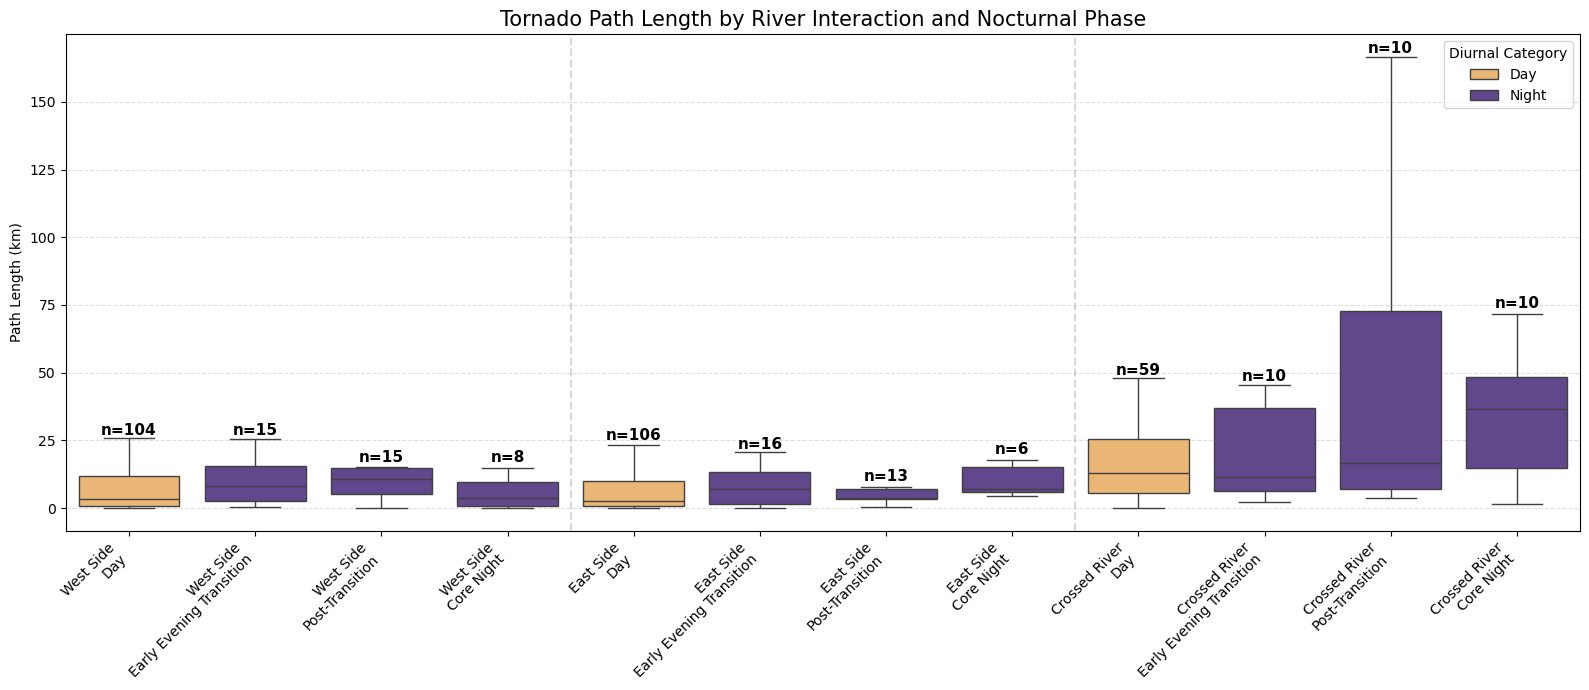

In [34]:
# ================================================================
# Boxplot: Path Length by Group and Nocturnal Bin
# ================================================================

plt.figure(figsize=(16,7))

# ------------------------------------------------
# Day vs Night color mapping
# ------------------------------------------------

df_plot["day_night_simple"] = df_plot["nocturnal_bin"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = [
    "West Side\nDay",
    "West Side\nEarly Evening Transition",
    "West Side\nPost-Transition",
    "West Side\nCore Night",

    "East Side\nDay",
    "East Side\nEarly Evening Transition",
    "East Side\nPost-Transition",
    "East Side\nCore Night",

    "Crossed River\nDay",
    "Crossed River\nEarly Evening Transition",
    "Crossed River\nPost-Transition",
    "Crossed River\nCore Night"
]

ax = sns.boxplot(
    data=df_plot,
    x="group_bin",
    y="len_km",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

# ------------------------------------------------
# Labels / formatting
# ------------------------------------------------

ax.set_title(
    "Tornado Path Length by River Interaction and Nocturnal Phase",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Diurnal Category")

plt.xticks(rotation=45, ha="right")

# Vertical separators between groups
for x in [3.5, 7.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_plot.groupby(["group","nocturnal_bin"]).size()

print("\nCounts used in boxplot:\n")
print(counts)

# ------------------------------------------------
# Add count labels (YOU WILL TUNE POSITIONS)
# ------------------------------------------------

positions = {

    # WEST SIDE
    ("West Side","Day"):(0,27),
    ("West Side","Early Evening Transition"):(1,27),
    ("West Side","Post-Transition"):(2,17),
    ("West Side","Core Night"):(3,17),

    # EAST SIDE
    ("East Side","Day"):(4,25),
    ("East Side","Early Evening Transition"):(5,22),
    ("East Side","Post-Transition"):(6,10),
    ("East Side","Core Night"):(7,20),

    # CROSSED RIVER
    ("Crossed River","Day"):(8,49),
    ("Crossed River","Early Evening Transition"):(9,47),
    ("Crossed River","Post-Transition"):(10,168),
    ("Crossed River","Core Night"):(11,74),
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [35]:
# ================================================================
# Prepare groups for statistical testing
# ================================================================

df_plot["group_bin_full"] = (
    df_plot["group"] + " " + df_plot["nocturnal_bin"]
)

groups = df_plot.groupby("group_bin_full")["len_km"].apply(list)

print("Groups included in analysis:")
print(groups.index.tolist())

Groups included in analysis:
['Crossed River Core Night', 'Crossed River Day', 'Crossed River Early Evening Transition', 'Crossed River Post-Transition', 'East Side Core Night', 'East Side Day', 'East Side Early Evening Transition', 'East Side Post-Transition', 'West Side Core Night', 'West Side Day', 'West Side Early Evening Transition', 'West Side Post-Transition']


In [36]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Path Lengths")
print("------------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Path Lengths
------------------------------------------------------
H = 52.389
p-value = 0.000000
Interpretation: At least one group differs significantly.


In [37]:
pairs = list(itertools.combinations(groups.index, 2))

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Core Night,Crossed River Day,3.112859,0.077676,No
1,Crossed River Core Night,Crossed River Early Evening Transition,1.042212,0.307308,No
2,Crossed River Core Night,Crossed River Post-Transition,0.142857,0.705457,No
3,Crossed River Core Night,East Side Core Night,2.647059,0.103742,No
4,Crossed River Core Night,East Side Day,11.931488,0.000552,Yes
...,...,...,...,...,...
61,West Side Core Night,West Side Early Evening Transition,0.505165,0.477239,No
62,West Side Core Night,West Side Post-Transition,1.204167,0.272490,No
63,West Side Day,West Side Early Evening Transition,1.274904,0.258849,No
64,West Side Day,West Side Post-Transition,3.556284,0.059320,No


In [38]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests

pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Core Night,Crossed River Day,3.112859,0.077676,No,5.126648,No
1,Crossed River Core Night,Crossed River Early Evening Transition,1.042212,0.307308,No,20.282297,No
2,Crossed River Core Night,Crossed River Post-Transition,0.142857,0.705457,No,46.560161,No
3,Crossed River Core Night,East Side Core Night,2.647059,0.103742,No,6.846951,No
4,Crossed River Core Night,East Side Day,11.931488,0.000552,Yes,0.036427,Yes
...,...,...,...,...,...,...,...
61,West Side Core Night,West Side Early Evening Transition,0.505165,0.477239,No,31.497801,No
62,West Side Core Night,West Side Post-Transition,1.204167,0.272490,No,17.984372,No
63,West Side Day,West Side Early Evening Transition,1.274904,0.258849,No,17.084011,No
64,West Side Day,West Side Post-Transition,3.556284,0.059320,No,3.915146,No


In [39]:
# ================================================================
# Extract significant comparisons
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Significant?"] == "Yes"].copy()

print("All significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
]])

# ================================================================
# Bonferroni-significant only
# ================================================================

significant_pairs = pairwise_df[pairwise_df["Adj Significant?"] == "Yes"].copy()

print("Bonferroni-significant comparisons:")
display(significant_pairs[[
    "Group1",
    "Group2",
    "H",
    "p-value",
    "Adj p-value (Bonferroni)"
]])

#Just a side note: If the study is highly exploratory, the Bonferroni correction may be too conservative and increase Type II errors (missing real differences).

All significant comparisons:


,Group1,Group2,H,p-value
4,Crossed River Core Night,East Side Day,11.931488,0.000552
5,Crossed River Core Night,East Side Early Evening Transition,5.136111,0.023433
6,Crossed River Core Night,East Side Post-Transition,6.465385,0.011000
7,Crossed River Core Night,West Side Core Night,4.547368,0.032969
8,Crossed River Core Night,West Side Day,10.765421,0.001034
9,Crossed River Core Night,West Side Early Evening Transition,5.052753,0.024587
14,Crossed River Day,East Side Day,23.599712,0.000001
16,Crossed River Day,East Side Post-Transition,7.656469,0.005657
17,Crossed River Day,West Side Core Night,4.122832,0.042308
18,Crossed River Day,West Side Day,21.035299,0.000005


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
4,Crossed River Core Night,East Side Day,11.931488,0.000552,0.036427
14,Crossed River Day,East Side Day,23.599712,0.000001,0.000078
18,Crossed River Day,West Side Day,21.035299,0.000005,0.000298


### Tornado Path Length by Nocturnal Phase and River Interaction

A Kruskal–Wallis test was conducted to evaluate differences in tornado path lengths across **12 groups**, representing West Side, East Side, and Crossed River tornadoes, each subdivided into **Day**, **Early Evening Transition**, **Post-Transition**, and **Core Night** periods.

Sample sizes across groups were uneven but sufficient, with the majority of tornadoes occurring during the **daytime**, and smaller but meaningful samples within the nocturnal transition bins.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 52.389**  
- **p < 0.001**

This result suggests that tornado path length distributions vary significantly as a function of both **river interaction** and **nocturnal phase**.

---

### Pairwise Comparisons

A total of **66 pairwise comparisons** were performed, with statistical significance evaluated both before and after applying a **Bonferroni correction** to control for multiple testing.

After correction, the following comparisons remained statistically significant:

- **Crossed River Core Night vs East Side Day**  
  (H = 11.93, adj. p = 0.036)

- **Crossed River Day vs East Side Day**  
  (H = 23.60, adj. p < 0.001)

- **Crossed River Day vs West Side Day**  
  (H = 21.04, adj. p < 0.001)

Additional comparisons that were significant prior to correction included:

- **Crossed River Post-Transition vs East Side Day**  
  (H = 9.73, p = 0.0018)

- **Crossed River Early Evening Transition vs East Side Day**  
  (H = 7.59, p = 0.0059)

- **Crossed River Core Night vs West Side Day**  
  (H = 10.77, p = 0.0010)

- **Crossed River Post-Transition vs West Side Day**  
  (H = 9.28, p = 0.0023)

---

### Interpretation

These results indicate that **both daytime and nocturnal tornadoes interacting directly with the river corridor (Crossed River)** tend to exhibit **significantly longer path lengths**, particularly when compared to **daytime tornadoes on the East Side and West Side**.

The strongest and most statistically robust differences involve:

- **Crossed River daytime tornadoes**, and  
- **Crossed River Core Night tornadoes**

relative to **East Side daytime tornadoes** and **West Side daytime tornadoes**.

Notably, the **Crossed River Day** group remained highly significant even after Bonferroni correction, suggesting a particularly strong signal associated with tornadoes directly crossing the river corridor during daytime conditions.

In contrast, most **within-group nocturnal comparisons** (e.g., Core Night vs Early Evening Transition within the same spatial category) did not remain significant after correction. This suggests that while nocturnal phase contributes to variability in tornado path length, the **dominant signal is associated with river interaction itself rather than finer-scale nocturnal timing differences**.

Overall, these findings support the hypothesis that the **Mississippi River corridor may enhance tornado persistence**, with additional but more subtle modulation by **nocturnal boundary layer evolution**, particularly during **Core Night** and the **post-sunset transition periods**.

In [40]:
# ================================================================
# Tornado Width by River Interaction and Nocturnal Phase
# ================================================================

# Assign group labels
west_side["group"] = "West Side"
east_side["group"] = "East Side"
crossing_tornadoes["group"] = "Crossed River"

# Combine
df_plot = pd.concat(
    [west_side, east_side, crossing_tornadoes],
    ignore_index=True
)

# ================================================================
# Convert tornado width from yards -> meters
# ================================================================

df_plot["wid_m"] = df_plot["wid"] * 0.9144

# Keep only relevant bins
valid_bins = [
    "Day",
    "Early Evening Transition",
    "Post-Transition",
    "Core Night"
]

df_plot = df_plot[
    df_plot["nocturnal_bin"].isin(valid_bins)
].copy()

# Create combined label
df_plot["group_bin"] = (
    df_plot["group"] + "\n" + df_plot["nocturnal_bin"]
)

print("\nCounts by group and bin:\n")

print(
    df_plot.groupby(["group","nocturnal_bin"]).size()
)


Counts by group and bin:

group          nocturnal_bin           
Crossed River  Core Night                   10
               Day                          59
               Early Evening Transition     10
               Post-Transition              10
East Side      Core Night                    6
               Day                         106
               Early Evening Transition     16
               Post-Transition              13
West Side      Core Night                    8
               Day                         104
               Early Evening Transition     15
               Post-Transition              15
dtype: int64



Counts used in boxplot:

group          nocturnal_bin           
Crossed River  Core Night                   10
               Day                          59
               Early Evening Transition     10
               Post-Transition              10
East Side      Core Night                    6
               Day                         106
               Early Evening Transition     16
               Post-Transition              13
West Side      Core Night                    8
               Day                         104
               Early Evening Transition     15
               Post-Transition              15
dtype: int64


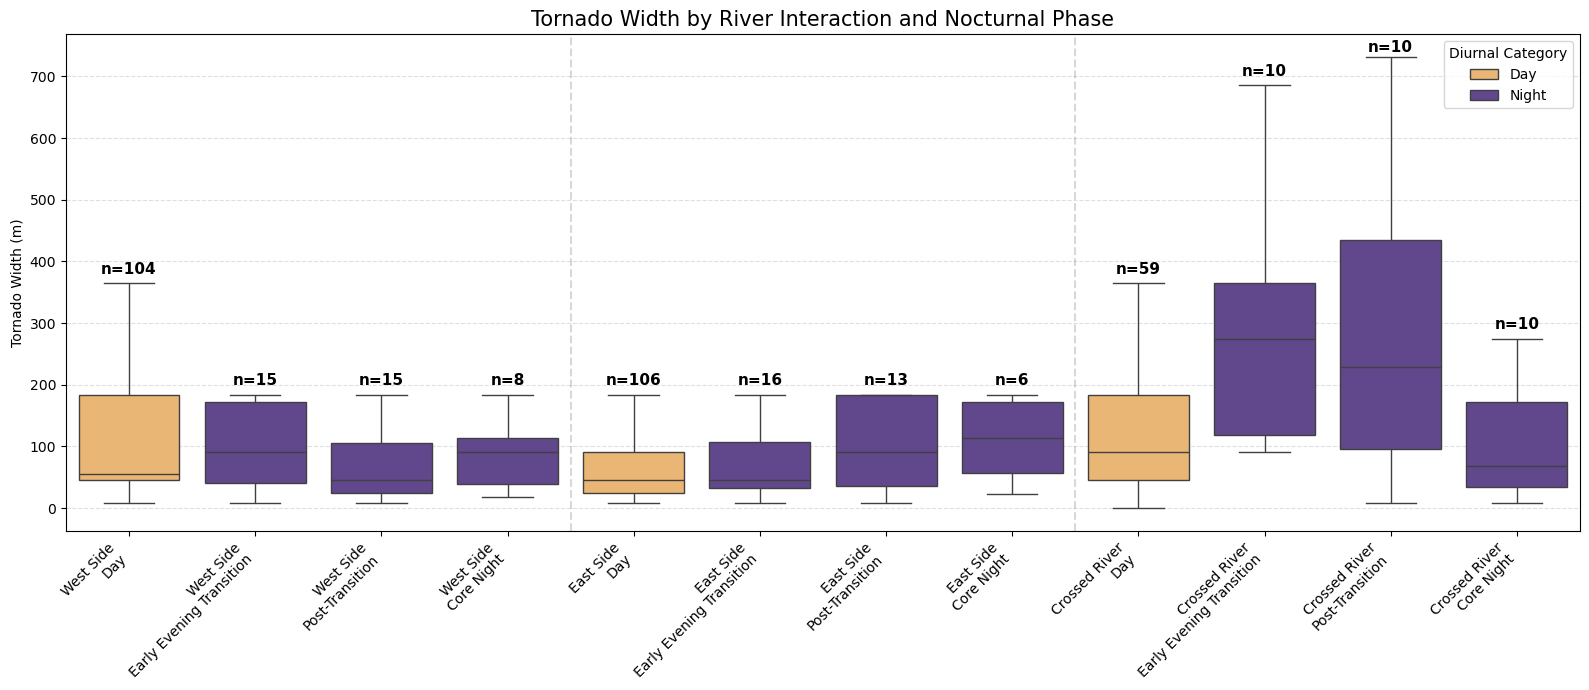

In [45]:

# ================================================================
# Boxplot: Tornado Width by Group and Nocturnal Bin
# ================================================================

plt.figure(figsize=(16,7))

# ------------------------------------------------
# Day vs Night color mapping
# ------------------------------------------------

df_plot["day_night_simple"] = df_plot["nocturnal_bin"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

order = [

    # WEST SIDE
    "West Side\nDay",
    "West Side\nEarly Evening Transition",
    "West Side\nPost-Transition",
    "West Side\nCore Night",

    # EAST SIDE
    "East Side\nDay",
    "East Side\nEarly Evening Transition",
    "East Side\nPost-Transition",
    "East Side\nCore Night",

    # CROSSED RIVER
    "Crossed River\nDay",
    "Crossed River\nEarly Evening Transition",
    "Crossed River\nPost-Transition",
    "Crossed River\nCore Night"
]

ax = sns.boxplot(
    data=df_plot,
    x="group_bin",
    y="wid_m",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

# ------------------------------------------------
# Labels / formatting
# ------------------------------------------------

ax.set_title(
    "Tornado Width by River Interaction and Nocturnal Phase",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")

ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()

by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Diurnal Category"
)

plt.xticks(rotation=45, ha="right")

# Vertical separators between groups
for x in [3.5, 7.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_plot.groupby(
    ["group","nocturnal_bin"]
).size()

print("\nCounts used in boxplot:\n")
print(counts)

# ------------------------------------------------
# Add count labels
# ------------------------------------------------

positions = {

    # WEST SIDE
    ("West Side","Day"):(0,380),
    ("West Side","Early Evening Transition"):(1,200),
    ("West Side","Post-Transition"):(2,200),
    ("West Side","Core Night"):(3,200),

    # EAST SIDE
    ("East Side","Day"):(4,200),
    ("East Side","Early Evening Transition"):(5,200),
    ("East Side","Post-Transition"):(6,200),
    ("East Side","Core Night"):(7,200),

    # CROSSED RIVER
    ("Crossed River","Day"):(8,380),
    ("Crossed River","Early Evening Transition"):(9,700),
    ("Crossed River","Post-Transition"):(10,740),
    ("Crossed River","Core Night"):(11,290),
}

for (grp,period),(x,y) in positions.items():

    n = counts.get((grp,period),0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [46]:
# ================================================================
# Prepare groups for statistical testing
# ================================================================

df_plot["group_bin_full"] = (
    df_plot["group"] + " " +
    df_plot["nocturnal_bin"]
)

groups = df_plot.groupby(
    "group_bin_full"
)["wid_m"].apply(list)

print("Groups included in analysis:")

print(groups.index.tolist())

Groups included in analysis:
['Crossed River Core Night', 'Crossed River Day', 'Crossed River Early Evening Transition', 'Crossed River Post-Transition', 'East Side Core Night', 'East Side Day', 'East Side Early Evening Transition', 'East Side Post-Transition', 'West Side Core Night', 'West Side Day', 'West Side Early Evening Transition', 'West Side Post-Transition']


In [47]:
# ================================================================
# Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal
import itertools

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths")
print("------------------------------------------------------")

print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: At least one group differs significantly.")
else:
    print("Interpretation: No statistically significant differences detected.")


Kruskal-Wallis Test on Tornado Widths
------------------------------------------------------
H = 39.851
p-value = 0.000038
Interpretation: At least one group differs significantly.


In [48]:
# ================================================================
# Pairwise Kruskal-Wallis Comparisons
# ================================================================

pairs = list(
    itertools.combinations(groups.index, 2)
)

results = []

for a, b in pairs:

    stat, p = kruskal(groups[a], groups[b])

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p,
        "Significant?": "Yes" if p < 0.05 else "No"
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")

display(pairwise_df)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Crossed River Core Night,Crossed River Day,0.543224,0.461100,No
1,Crossed River Core Night,Crossed River Early Evening Transition,6.137232,0.013236,Yes
2,Crossed River Core Night,Crossed River Post-Transition,2.916983,0.087652,No
3,Crossed River Core Night,East Side Core Night,0.360119,0.548440,No
4,Crossed River Core Night,East Side Day,1.084622,0.297666,No
...,...,...,...,...,...
61,West Side Core Night,West Side Early Evening Transition,0.017011,0.896228,No
62,West Side Core Night,West Side Post-Transition,0.270815,0.602786,No
63,West Side Day,West Side Early Evening Transition,0.011036,0.916334,No
64,West Side Day,West Side Post-Transition,1.928625,0.164909,No


In [49]:
# ================================================================
# Bonferroni Correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")

display(pairwise_df)


Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Crossed River Core Night,Crossed River Day,0.543224,0.461100,No,30.432586,No
1,Crossed River Core Night,Crossed River Early Evening Transition,6.137232,0.013236,Yes,0.873605,No
2,Crossed River Core Night,Crossed River Post-Transition,2.916983,0.087652,No,5.785008,No
3,Crossed River Core Night,East Side Core Night,0.360119,0.548440,No,36.197048,No
4,Crossed River Core Night,East Side Day,1.084622,0.297666,No,19.645955,No
...,...,...,...,...,...,...,...
61,West Side Core Night,West Side Early Evening Transition,0.017011,0.896228,No,59.151076,No
62,West Side Core Night,West Side Post-Transition,0.270815,0.602786,No,39.783870,No
63,West Side Day,West Side Early Evening Transition,0.011036,0.916334,No,60.478065,No
64,West Side Day,West Side Post-Transition,1.928625,0.164909,No,10.883991,No


In [50]:
# ================================================================
# Extract significant comparisons
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Significant?"] == "Yes"
].copy()

print("All significant comparisons:")

display(
    significant_pairs[[
        "Group1",
        "Group2",
        "H",
        "p-value",
    ]]
)

# ================================================================
# Bonferroni-significant only
# ================================================================

significant_pairs = pairwise_df[
    pairwise_df["Adj Significant?"] == "Yes"
].copy()

print("Bonferroni-significant comparisons:")

display(
    significant_pairs[[
        "Group1",
        "Group2",
        "H",
        "p-value",
        "Adj p-value (Bonferroni)"
    ]]
)

# Just a side note:
# If the study is highly exploratory, the Bonferroni correction
# may be too conservative and increase Type II errors
# (missing real differences).

All significant comparisons:


,Group1,Group2,H,p-value
1,Crossed River Core Night,Crossed River Early Evening Transition,6.137232,0.013236
11,Crossed River Day,Crossed River Early Evening Transition,6.999859,0.008152
14,Crossed River Day,East Side Day,16.224199,0.000056
23,Crossed River Early Evening Transition,East Side Day,17.909090,0.000023
24,Crossed River Early Evening Transition,East Side Early Evening Transition,8.768066,0.003066
25,Crossed River Early Evening Transition,East Side Post-Transition,6.452105,0.011082
26,Crossed River Early Evening Transition,West Side Core Night,6.227462,0.012578
27,Crossed River Early Evening Transition,West Side Day,11.139527,0.000845
28,Crossed River Early Evening Transition,West Side Early Evening Transition,7.476839,0.006250
29,Crossed River Early Evening Transition,West Side Post-Transition,8.410575,0.003730


Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)
14,Crossed River Day,East Side Day,16.224199,0.000056,0.003714
23,Crossed River Early Evening Transition,East Side Day,17.909090,0.000023,0.001529


### Tornado Width by Nocturnal Phase and River Interaction

A Kruskal–Wallis test was conducted to evaluate differences in tornado widths across **12 groups**, representing West Side, East Side, and Crossed River tornadoes, each subdivided into **Day**, **Early Evening Transition**, **Post-Transition**, and **Core Night** periods.

Sample sizes across groups were uneven but sufficient, with the majority of tornadoes occurring during the **daytime** and progressively fewer tornadoes occurring during the nocturnal transition and core nighttime periods.

The Kruskal–Wallis test indicated a statistically significant difference among groups:

- **H = 39.851**  
- **p < 0.001**

This result suggests that tornado width distributions vary significantly as a function of both **river interaction** and **nocturnal phase**.

---

### Pairwise Comparisons

A total of **66 pairwise comparisons** were performed, with statistical significance evaluated both before and after applying a **Bonferroni correction** to control for multiple testing.

After correction, the following comparisons remained statistically significant:

- **Crossed River Day vs East Side Day**  
  (H = 16.22, adj. p = 0.0037)

- **Crossed River Early Evening Transition vs East Side Day**  
  (H = 17.91, adj. p = 0.0015)

Additional comparisons that were significant prior to correction included:

- **Crossed River Early Evening Transition vs West Side Day**  
  (H = 11.14, p = 0.0008)

- **Crossed River Post-Transition vs East Side Day**  
  (H = 9.35, p = 0.0022)

- **Crossed River Day vs Crossed River Early Evening Transition**  
  (H = 7.00, p = 0.0082)

- **East Side Day vs West Side Day**  
  (H = 10.99, p = 0.0009)

- **Crossed River Early Evening Transition vs East Side Early Evening Transition**  
  (H = 8.77, p = 0.0031)

---

### Interpretation

These results indicate that tornadoes directly interacting with the river corridor—particularly during the **Early Evening Transition** and **daytime periods**—tend to exhibit **significantly larger tornado widths** than nearby daytime tornado populations on the **East Side** of the river.

The strongest and most statistically robust signals are concentrated specifically in:

- **Crossed River daytime tornadoes**, and  
- **Crossed River Early Evening Transition tornadoes**

both of which remained significant after Bonferroni correction when compared to **East Side daytime tornadoes**.

Additional nominally significant comparisons suggest that:
- Crossed River Post-Transition tornadoes may also exhibit enhanced widths relative to East Side daytime populations
- Crossed River Early Evening Transition tornadoes tend to be wider than several West Side and East Side transition populations
- Within the Crossed River population itself, Early Evening Transition tornadoes differed from daytime tornadoes, suggesting meaningful nocturnal-phase variability within river-interacting environments

Importantly, most comparisons confined solely to West Side or East Side populations remained weak or non-significant across nocturnal phases. This suggests that the dominant tornado-width signal is associated more strongly with **direct river interaction** than with nocturnal timing alone.

Overall, these findings provide strong evidence that tornadoes interacting directly with the Mississippi River corridor—especially during the **Early Evening Transition period**—may exhibit enhanced tornado width characteristics. These results complement earlier path length analyses and support the hypothesis that river–boundary interactions and evolving nocturnal boundary-layer conditions can influence tornado structure and intensity during the post-sunset transition period.

In [61]:
# ================================================================
# Prepare Buffer/River vs Controls (Intensity-Matched)
# ================================================================

np.random.seed(42)

# Combine Buffer/River population
buffer_river = pd.concat([west_side, east_side, crossing_tornadoes]).copy()
buffer_river["group"] = "Buffer/River"

# Assign control labels
west_control["group"] = "West Control"
east_control["group"] = "East Control"

# Convert path length
for df in [buffer_river, west_control, east_control]:
    df["len_km"] = df["len"] * 1.60934

# ------------------------------------------------
# Function: intensity-matched sampling
# ------------------------------------------------

def sample_controls_by_intensity(buffer_df, control_df):

    samples = []

    for mag in sorted(buffer_df["mag"].unique()):

        n = (buffer_df["mag"] == mag).sum()

        control_subset = control_df[control_df["mag"] == mag]

        if len(control_subset) >= n:
            sampled = control_subset.sample(n=n, replace=False)
        else:
            # fallback: allow replacement if needed
            sampled = control_subset.sample(n=n, replace=True)

        samples.append(sampled)

    return pd.concat(samples)

# ------------------------------------------------
# Apply sampling
# ------------------------------------------------

west_sample = sample_controls_by_intensity(buffer_river, west_control)
east_sample = sample_controls_by_intensity(buffer_river, east_control)

# Combine final dataset
df_compare = pd.concat([buffer_river, west_sample, east_sample], ignore_index=True)

print("\nCounts by group:")
print(df_compare["group"].value_counts())

print("\nCounts by EF-scale:")
print(df_compare.groupby(["group","mag"]).size())


Counts by group:
group
Buffer/River    372
West Control    372
East Control    372
Name: count, dtype: int64

Counts by EF-scale:
group         mag
Buffer/River  0      124
              1      122
              2       79
              3       37
              4       10
East Control  0      124
              1      122
              2       79
              3       37
              4       10
West Control  0      124
              1      122
              2       79
              3       37
              4       10
dtype: int64



Counts used in boxplot:

group         nocturnal_bin           
Buffer/River  Core Night                   24
              Day                         269
              Early Evening Transition     41
              Post-Transition              38
East Control  Core Night                   27
              Day                         283
              Early Evening Transition     39
              Post-Transition              23
West Control  Core Night                   29
              Day                         279
              Early Evening Transition     34
              Post-Transition              30
dtype: int64


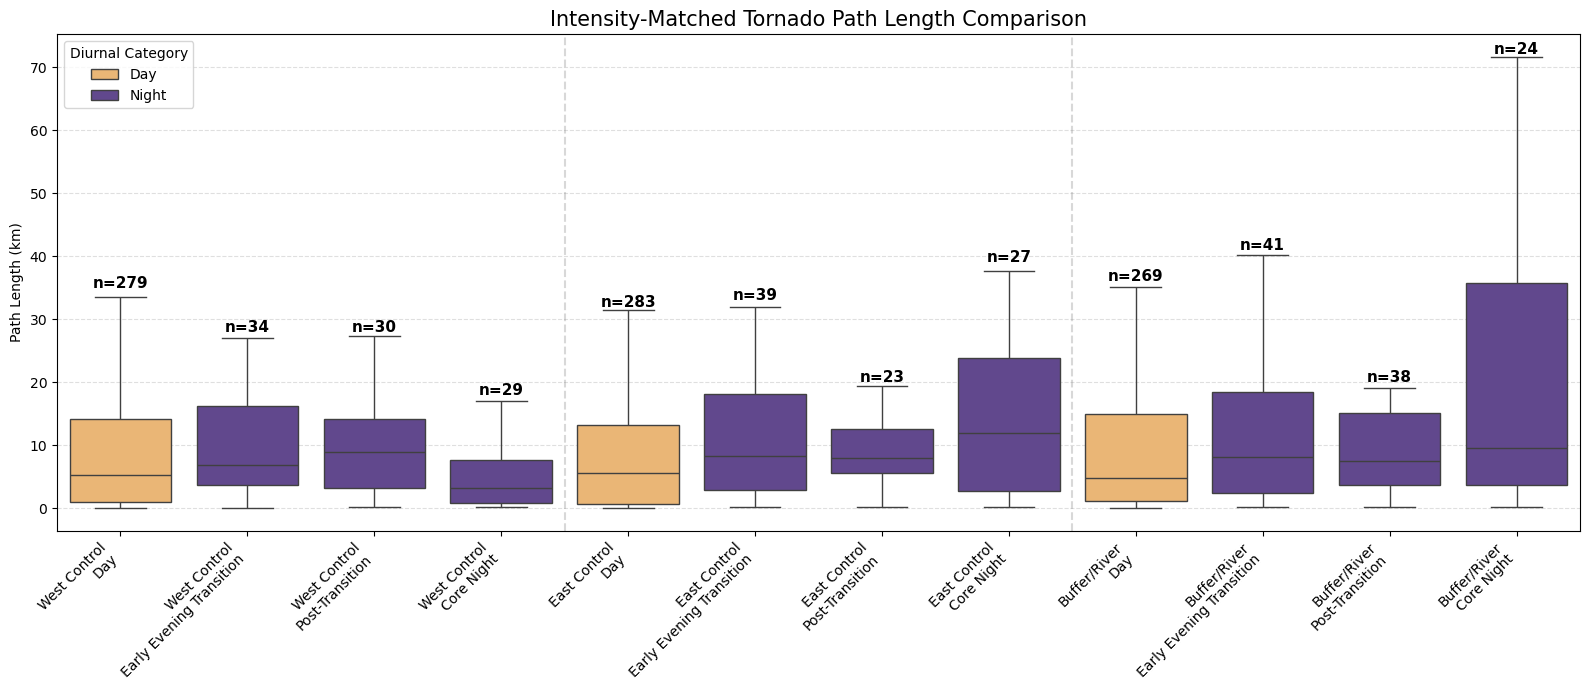


Five-number summary (km):

                                            Min        Q1     Median  \
group        nocturnal_bin                                             
Buffer/River Core Night                0.160934  3.737692   9.495106   
             Day                       0.000000  1.094351   4.828020   
             Early Evening Transition  0.160934  2.414010   8.046700   
             Post-Transition           0.177027  3.721599   7.531711   
East Control Core Night                0.241401  2.719785  11.876929   
             Day                       0.016093  0.692016   5.584410   
             Early Evening Transition  0.160934  2.945092   8.207634   
             Post-Transition           0.177027  5.632690   7.885766   
West Control Core Night                0.144841  0.788577   3.218680   
             Day                       0.000000  0.941464   5.310822   
             Early Evening Transition  0.000000  3.669295   6.920162   
             Post-Transition        

In [62]:
# ================================================================
# Prepare bins
# ================================================================

valid_bins = ["Day", "Early Evening Transition", "Post-Transition", "Core Night"]

df_compare = df_compare[df_compare["nocturnal_bin"].isin(valid_bins)].copy()

df_compare["group_bin"] = df_compare["group"] + "\n" + df_compare["nocturnal_bin"]

# Day vs Night color
df_compare["day_night_simple"] = df_compare["nocturnal_bin"].apply(
    lambda x: "Day" if x == "Day" else "Night"
)

palette = {"Day":"#FDB863", "Night":"#5E3C99"}

order = [
    "West Control\nDay","West Control\nEarly Evening Transition","West Control\nPost-Transition","West Control\nCore Night",
    "East Control\nDay","East Control\nEarly Evening Transition","East Control\nPost-Transition","East Control\nCore Night",
    "Buffer/River\nDay","Buffer/River\nEarly Evening Transition","Buffer/River\nPost-Transition","Buffer/River\nCore Night"
]

# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(16,7))

ax = sns.boxplot(
    data=df_compare,
    x="group_bin",
    y="len_km",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title("Intensity-Matched Tornado Path Length Comparison", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Diurnal Category")

plt.xticks(rotation=45, ha="right")

# separators
for x in [3.5, 7.5]:
    plt.axvline(x, color="gray", linestyle="--", alpha=0.3)

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_compare.groupby(["group","nocturnal_bin"]).size()

print("\nCounts used in boxplot:\n")
print(counts)

positions = {

    # WEST CONTROL
    ("West Control","Day"):(0,35),
    ("West Control","Early Evening Transition"):(1,28),
    ("West Control","Post-Transition"):(2,28),
    ("West Control","Core Night"):(3,18),

    # EAST CONTROL
    ("East Control","Day"):(4,32),
    ("East Control","Early Evening Transition"):(5,33),
    ("East Control","Post-Transition"):(6,20),
    ("East Control","Core Night"):(7,39),

    # BUFFER / RIVER
    ("Buffer/River","Day"):(8,36),
    ("Buffer/River","Early Evening Transition"):(9,41),
    ("Buffer/River","Post-Transition"):(10,20),
    ("Buffer/River","Core Night"):(11,72),
}

for (grp, period), (x, y) in positions.items():

    n = counts.get((grp, period), 0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

summary = (
    df_compare.groupby(["group","nocturnal_bin"])["len_km"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = ["Min","Q1","Median","Q3","Max"]

print("\nFive-number summary (km):\n")
print(summary)

In [63]:
# ================================================================
# Overall Kruskal-Wallis Test
# ================================================================

from scipy.stats import kruskal

# ------------------------------------------------
# Create combined group labels
# ------------------------------------------------
df_compare["group_bin_full"] = (
    df_compare["group"] + " " + df_compare["nocturnal_bin"]
)

# ------------------------------------------------
# Extract groups
# ------------------------------------------------
groups = (
    df_compare
    .groupby("group_bin_full")["len_km"]
    .apply(list)
)

# ------------------------------------------------
# Run overall Kruskal-Wallis
# ------------------------------------------------
H, p = kruskal(*groups.tolist())

print("\nOverall Kruskal-Wallis Test")
print("--------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

if p < 0.05:
    print("Interpretation: Significant difference among groups.")
else:
    print("Interpretation: No significant difference among groups.")


Overall Kruskal-Wallis Test
--------------------------------
H = 26.338
p-value = 0.005779
Interpretation: Significant difference among groups.


In [64]:
# ================================================================
# STEP 1: Pairwise Kruskal-Wallis Comparisons
# ================================================================

import itertools
import numpy as np
import pandas as pd
from scipy.stats import kruskal

# ------------------------------------------------
# Build groups from current dataframe
# ------------------------------------------------
groups = (
    df_compare
    .groupby("group_bin_full")["len_km"]
    .apply(list)
)

group_names = groups.index.tolist()

# ------------------------------------------------
# Pairwise comparisons
# ------------------------------------------------
results = []

for g1, g2 in itertools.combinations(group_names, 2):

    data1 = groups[g1]
    data2 = groups[g2]

    try:

        H_pair, p_pair = kruskal(data1, data2)

        results.append({
            "Group1": g1,
            "Group2": g2,
            "H": H_pair,
            "p-value": p_pair,
            "Significant?": "Yes" if p_pair < 0.05 else "No"
        })

    except Exception as e:

        print(f"Error comparing {g1} vs {g2}: {e}")

# ------------------------------------------------
# Convert to dataframe
# ------------------------------------------------
pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")
display(pairwise_df)

# ================================================================
# STEP 2: Bonferroni Correction
# ================================================================

# ------------------------------------------------
# Number of tests
# ------------------------------------------------
n_tests = len(pairwise_df)

# ------------------------------------------------
# Adjusted p-values
# ------------------------------------------------
pairwise_df["Adj p-value (Bonferroni)"] = np.minimum(
    pairwise_df["p-value"] * n_tests,
    1.0
)

# ------------------------------------------------
# Adjusted significance
# ------------------------------------------------
pairwise_df["Adj Significant?"] = pairwise_df[
    "Adj p-value (Bonferroni)"
].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")
display(pairwise_df)

# ================================================================
# STEP 3: Extract Significant Comparisons
# ================================================================

# ------------------------------------------------
# Raw significant comparisons
# ------------------------------------------------
print("\nAll significant comparisons:")
display(
    pairwise_df[
        pairwise_df["Significant?"] == "Yes"
    ][[
        "Group1",
        "Group2",
        "H",
        "p-value"
    ]]
)

# ------------------------------------------------
# Bonferroni-significant comparisons
# ------------------------------------------------
print("\nBonferroni-significant comparisons:")
display(
    pairwise_df[
        pairwise_df["Adj Significant?"] == "Yes"
    ][[
        "Group1",
        "Group2",
        "H",
        "p-value",
        "Adj p-value (Bonferroni)"
    ]]
)


Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Core Night,Buffer/River Day,5.289282,0.021457,Yes
1,Buffer/River Core Night,Buffer/River Early Evening Transition,0.842174,0.358776,No
2,Buffer/River Core Night,Buffer/River Post-Transition,0.368440,0.543856,No
3,Buffer/River Core Night,East Control Core Night,0.080132,0.777119,No
4,Buffer/River Core Night,East Control Day,6.037406,0.014006,Yes
...,...,...,...,...,...
61,West Control Core Night,West Control Early Evening Transition,3.494027,0.061591,No
62,West Control Core Night,West Control Post-Transition,5.960244,0.014632,Yes
63,West Control Day,West Control Early Evening Transition,1.009925,0.314921,No
64,West Control Day,West Control Post-Transition,2.168302,0.140882,No



Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Core Night,Buffer/River Day,5.289282,0.021457,Yes,1.000000,No
1,Buffer/River Core Night,Buffer/River Early Evening Transition,0.842174,0.358776,No,1.000000,No
2,Buffer/River Core Night,Buffer/River Post-Transition,0.368440,0.543856,No,1.000000,No
3,Buffer/River Core Night,East Control Core Night,0.080132,0.777119,No,1.000000,No
4,Buffer/River Core Night,East Control Day,6.037406,0.014006,Yes,0.924386,No
...,...,...,...,...,...,...,...
61,West Control Core Night,West Control Early Evening Transition,3.494027,0.061591,No,1.000000,No
62,West Control Core Night,West Control Post-Transition,5.960244,0.014632,Yes,0.965713,No
63,West Control Day,West Control Early Evening Transition,1.009925,0.314921,No,1.000000,No
64,West Control Day,West Control Post-Transition,2.168302,0.140882,No,1.000000,No



All significant comparisons:


,Group1,Group2,H,p-value
0,Buffer/River Core Night,Buffer/River Day,5.289282,0.021457
4,Buffer/River Core Night,East Control Day,6.037406,0.014006
7,Buffer/River Core Night,West Control Core Night,7.475946,0.006253
8,Buffer/River Core Night,West Control Day,5.499044,0.019027
12,Buffer/River Day,Buffer/River Post-Transition,4.816679,0.028186
13,Buffer/River Day,East Control Core Night,4.740807,0.029455
26,Buffer/River Early Evening Transition,West Control Core Night,5.323835,0.021036
31,Buffer/River Post-Transition,East Control Day,4.832365,0.027930
34,Buffer/River Post-Transition,West Control Core Night,7.963912,0.004772
35,Buffer/River Post-Transition,West Control Day,4.219505,0.039962



Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


In [65]:
# ================================================================
# Bootstrap testing (FIXED)
# ================================================================

n_boot = 10000
p_values = []

for i in range(n_boot):

    west_sample = sample_controls_by_intensity(buffer_river, west_control)
    east_sample = sample_controls_by_intensity(buffer_river, east_control)

    # IMPORTANT: reassign group labels
    west_sample["group"] = "West Control"
    east_sample["group"] = "East Control"

    df_boot = pd.concat([buffer_river, west_sample, east_sample])

    df_boot = df_boot[df_boot["nocturnal_bin"].isin(valid_bins)].copy()

    df_boot["group_bin_full"] = (
        df_boot["group"] + " " + df_boot["nocturnal_bin"]
    )

    groups_boot = df_boot.groupby("group_bin_full")["len_km"].apply(list)

    try:
        H, p = kruskal(*groups_boot)
        p_values.append(p)
    except:
        continue

# ------------------------------------------------
# Results
# ------------------------------------------------
p_values = np.array(p_values)

print("\nBootstrap Results:")
print("Mean p-value:", np.mean(p_values))
print("Median p-value:", np.median(p_values))
print("Fraction significant (p < 0.05):", np.mean(p_values < 0.05))


Bootstrap Results:
Mean p-value: 0.02174807144548446
Median p-value: 0.008555917610741343
Fraction significant (p < 0.05): 0.8681


In [66]:
print(buffer_river["nocturnal_bin"].value_counts(dropna=False))
print(west_control["nocturnal_bin"].value_counts(dropna=False))
print(east_control["nocturnal_bin"].value_counts(dropna=False))

print(buffer_river["nocturnal_bin"].isna().sum())
print(west_control["nocturnal_bin"].isna().sum())
print(east_control["nocturnal_bin"].isna().sum())

print(tornado_csv)

nocturnal_bin
Day                         269
Early Evening Transition     41
Post-Transition              38
Core Night                   24
Name: count, dtype: int64
nocturnal_bin
Day                         2589
Early Evening Transition     388
Post-Transition              297
Core Night                   280
Name: count, dtype: int64
nocturnal_bin
Day                         1445
Early Evening Transition     226
Post-Transition              107
Core Night                    89
Name: count, dtype: int64
0
0
0
/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_EET_bins.csv


### Tornado Path Lengths by Early Evening Transition (EET) Framework

A Kruskal–Wallis test was conducted to evaluate differences in tornado path lengths across **12 groups**, representing Buffer/River, West Control, and East Control populations subdivided into **Day, Early Evening Transition (EET), Post-Transition, and Core Night** periods.

The test indicated a statistically significant difference among groups:

- **H = 26.338**  
- **p = 0.0058**

This suggests that at least one group exhibits significantly different path length characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests revealed multiple statistically significant differences at the **α = 0.05 level**, particularly involving Buffer/River tornadoes and nocturnal control populations:

- **Buffer/River Core Night vs Buffer/River Day**  
  (H = 5.29, p = 0.021)

- **Buffer/River Core Night vs East Control Day**  
  (H = 6.04, p = 0.014)

- **Buffer/River Core Night vs West Control Core Night**  
  (H = 7.48, p = 0.006)

- **Buffer/River Post-Transition vs West Control Core Night**  
  (H = 7.96, p = 0.0048)

- **East Control Core Night vs East Control Day**  
  (H = 6.13, p = 0.013)

- **East Control Core Night vs West Control Core Night**  
  (H = 6.67, p = 0.0098)

However, after applying a **Bonferroni correction (66 comparisons)**:

- **No pairwise comparisons remained statistically significant**

This indicates that while several nominally significant differences exist, individual pairwise contrasts are sensitive to strict multiple-testing correction.

### Distributional Insights

The statistical comparisons suggest several important patterns:

- **Buffer/River tornadoes** generally exhibit longer path lengths during:
  - **Core Night**
  - **Early Evening Transition**
  - **Post-Transition**
  
  relative to their daytime counterparts and several control populations.

- **East Control Core Night** tornadoes also exhibit enhanced path lengths relative to East Control daytime tornadoes, suggesting a broader nocturnal signal beyond the river corridor itself.

- **West Control Core Night** tornadoes repeatedly appeared among the shorter-path populations, particularly when compared against Buffer/River nocturnal groups.

### Bootstrap Robustness

Bootstrapping using repeated intensity-matched resampling confirms the robustness of the overall result:

- **Mean p-value:** 0.0217  
- **Median p-value:** 0.0086  
- **Fraction significant (p < 0.05): 86.8%**

This indicates that the detected group differences are **consistently reproduced across resampled datasets**, even though no individual pairwise comparison survives the conservative Bonferroni correction.

### Interpretation

These results suggest that:

- **Tornadoes interacting with the river corridor (Buffer/River)** tend to exhibit **longer path lengths than several control populations**, particularly during nocturnal periods.
- The **Early Evening Transition and Post-Transition periods**—associated with evolving boundary layer structure and strengthening low-level shear—show evidence of enhanced tornado persistence relative to daytime conditions.
- **Core Night tornadoes** within both Buffer/River and East Control populations also tend to exhibit longer path lengths, supporting the role of **nocturnal environmental processes** in tornado longevity.

At the same time, the lack of Bonferroni-significant pairwise comparisons suggests that the signal is **moderate in magnitude and distributed across multiple related group contrasts rather than dominated by a single extreme comparison**.

Overall, these findings provide strong evidence that **both river interaction and nocturnal boundary-layer evolution—particularly during and after the Early Evening Transition—contribute to enhanced tornado persistence**, with the overall signal remaining highly robust under repeated intensity-matched bootstrap resampling.

In [67]:
# ================================================================
# Prepare Buffer/River vs Controls (Intensity-Matched)
# Tornado WIDTH version (yards -> meters)
# ================================================================

np.random.seed(42)

# Combine Buffer/River population
buffer_river = pd.concat(
    [west_side, east_side, crossing_tornadoes]
).copy()

buffer_river["group"] = "Buffer/River"

# Assign control labels
west_control["group"] = "West Control"
east_control["group"] = "East Control"

# ================================================================
# Convert tornado width from yards -> meters
# ================================================================

for df in [buffer_river, west_control, east_control]:
    df["wid_m"] = df["wid"] * 0.9144

# ------------------------------------------------
# Function: intensity-matched sampling
# ------------------------------------------------

def sample_controls_by_intensity(buffer_df, control_df):

    samples = []

    for mag in sorted(buffer_df["mag"].unique()):

        n = (buffer_df["mag"] == mag).sum()

        control_subset = control_df[
            control_df["mag"] == mag
        ]

        if len(control_subset) >= n:

            sampled = control_subset.sample(
                n=n,
                replace=False
            )

        else:
            # fallback: allow replacement if needed

            sampled = control_subset.sample(
                n=n,
                replace=True
            )

        samples.append(sampled)

    return pd.concat(samples)

# ------------------------------------------------
# Apply sampling
# ------------------------------------------------

west_sample = sample_controls_by_intensity(
    buffer_river,
    west_control
)

east_sample = sample_controls_by_intensity(
    buffer_river,
    east_control
)

# Combine final dataset
df_compare = pd.concat(
    [buffer_river, west_sample, east_sample],
    ignore_index=True
)

print("\nCounts by group:")

print(
    df_compare["group"].value_counts()
)

print("\nCounts by EF-scale:")

print(
    df_compare.groupby(["group","mag"]).size()
)



Counts by group:
group
Buffer/River    372
West Control    372
East Control    372
Name: count, dtype: int64

Counts by EF-scale:
group         mag
Buffer/River  0      124
              1      122
              2       79
              3       37
              4       10
East Control  0      124
              1      122
              2       79
              3       37
              4       10
West Control  0      124
              1      122
              2       79
              3       37
              4       10
dtype: int64



Counts used in boxplot:

group         nocturnal_bin           
Buffer/River  Core Night                   24
              Day                         269
              Early Evening Transition     41
              Post-Transition              38
East Control  Core Night                   27
              Day                         283
              Early Evening Transition     39
              Post-Transition              23
West Control  Core Night                   29
              Day                         279
              Early Evening Transition     34
              Post-Transition              30
dtype: int64


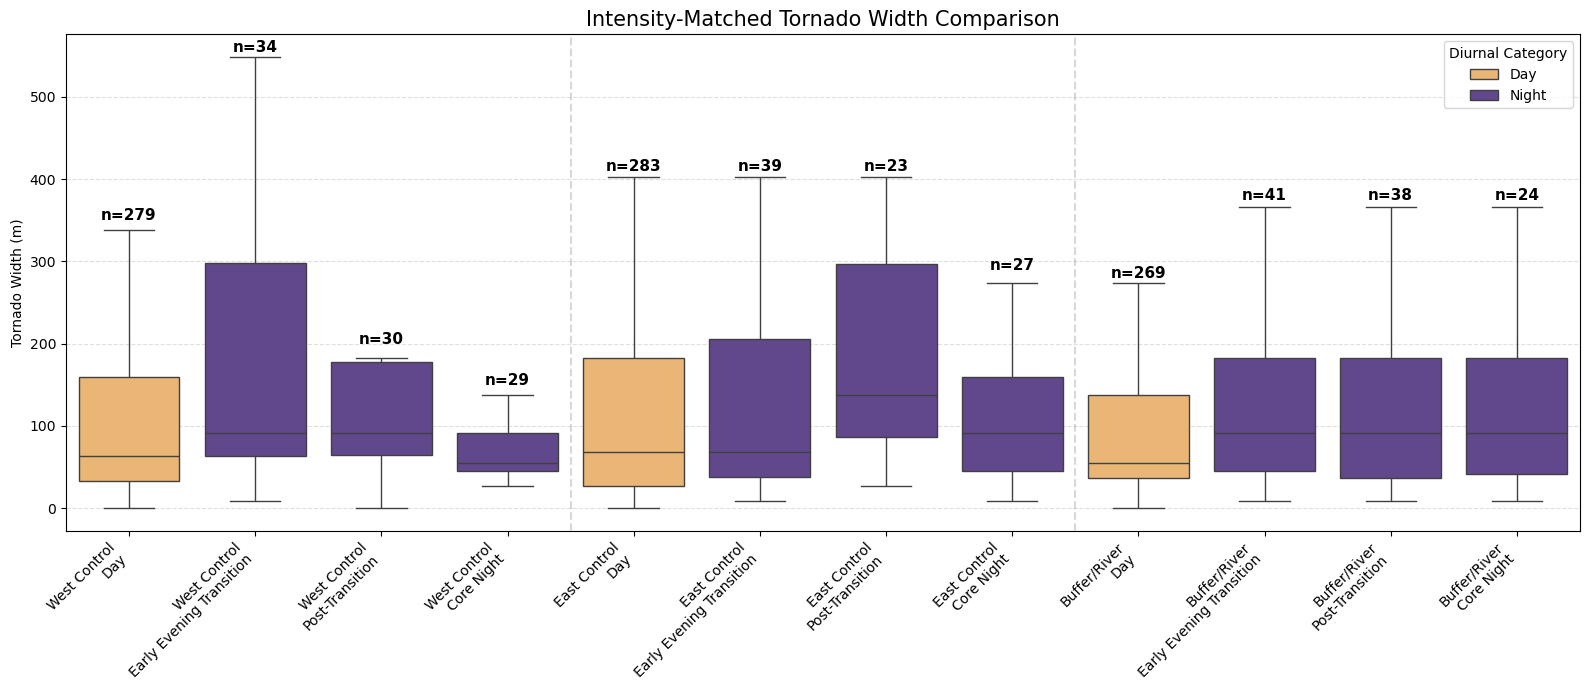


Five-number summary (meters):

                                          Min       Q1   Median        Q3  \
group        nocturnal_bin                                                  
Buffer/River Core Night                 9.144  41.8338   91.440  182.8800   
             Day                        0.000  36.5760   54.864  137.1600   
             Early Evening Transition   9.144  45.7200   91.440  182.8800   
             Post-Transition            9.144  36.5760   91.440  182.8800   
East Control Core Night                 9.144  45.7200   91.440  160.0200   
             Day                        0.000  27.4320   68.580  182.8800   
             Early Evening Transition   9.144  37.9476   68.580  205.7400   
             Post-Transition           27.432  86.8680  137.160  297.1800   
West Control Core Night                27.432  45.7200   54.864   91.4400   
             Day                        0.000  33.3756   64.008  159.1056   
             Early Evening Transition   9.14

In [68]:
# ================================================================
# Prepare bins
# ================================================================

valid_bins = [
    "Day",
    "Early Evening Transition",
    "Post-Transition",
    "Core Night"
]

df_compare = df_compare[
    df_compare["nocturnal_bin"].isin(valid_bins)
].copy()

df_compare["group_bin"] = (
    df_compare["group"] + "\n" +
    df_compare["nocturnal_bin"]
)

# ------------------------------------------------
# Day vs Night color
# ------------------------------------------------

df_compare["day_night_simple"] = (
    df_compare["nocturnal_bin"]
    .apply(lambda x: "Day" if x == "Day" else "Night")
)

palette = {
    "Day":"#FDB863",
    "Night":"#5E3C99"
}

order = [

    # WEST CONTROL
    "West Control\nDay",
    "West Control\nEarly Evening Transition",
    "West Control\nPost-Transition",
    "West Control\nCore Night",

    # EAST CONTROL
    "East Control\nDay",
    "East Control\nEarly Evening Transition",
    "East Control\nPost-Transition",
    "East Control\nCore Night",

    # BUFFER / RIVER
    "Buffer/River\nDay",
    "Buffer/River\nEarly Evening Transition",
    "Buffer/River\nPost-Transition",
    "Buffer/River\nCore Night"
]

# ================================================================
# Plot
# ================================================================

plt.figure(figsize=(16,7))

ax = sns.boxplot(
    data=df_compare,
    x="group_bin",
    y="wid_m",
    order=order,
    hue="day_night_simple",
    palette=palette,
    showfliers=False
)

ax.set_title(
    "Intensity-Matched Tornado Width Comparison",
    fontsize=15
)

ax.set_xlabel("")
ax.set_ylabel("Tornado Width (m)")

ax.grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------
# Clean legend
# ------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Diurnal Category"
)

plt.xticks(rotation=45, ha="right")

# separators
for x in [3.5, 7.5]:
    plt.axvline(
        x,
        color="gray",
        linestyle="--",
        alpha=0.3
    )

# ------------------------------------------------
# Compute counts for each box
# ------------------------------------------------

counts = df_compare.groupby(
    ["group","nocturnal_bin"]
).size()

print("\nCounts used in boxplot:\n")

print(counts)

# ------------------------------------------------
# Manual count labels
# ------------------------------------------------

positions = {

    # WEST CONTROL
    ("West Control","Day"):(0,350),
    ("West Control","Early Evening Transition"):(1,555),
    ("West Control","Post-Transition"):(2,200),
    ("West Control","Core Night"):(3,150),

    # EAST CONTROL
    ("East Control","Day"):(4,410),
    ("East Control","Early Evening Transition"):(5,410),
    ("East Control","Post-Transition"):(6,410),
    ("East Control","Core Night"):(7,290),

    # BUFFER / RIVER
    ("Buffer/River","Day"):(8,280),
    ("Buffer/River","Early Evening Transition"):(9,375),
    ("Buffer/River","Post-Transition"):(10,375),
    ("Buffer/River","Core Night"):(11,375),
}

for (grp, period), (x, y) in positions.items():

    n = counts.get((grp, period), 0)

    ax.text(
        x,
        y,
        f"n={n}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ================================================================
# Five-number summary
# ================================================================

summary = (
    df_compare.groupby(
        ["group","nocturnal_bin"]
    )["wid_m"]
    .describe(percentiles=[0.25,0.5,0.75])
    [["min","25%","50%","75%","max"]]
)

summary.columns = [
    "Min",
    "Q1",
    "Median",
    "Q3",
    "Max"
]

print("\nFive-number summary (meters):\n")

print(summary)

In [69]:
# ================================================================
# Statistical testing
# ================================================================

df_compare["group_bin_full"] = (
    df_compare["group"] + " " +
    df_compare["nocturnal_bin"]
)

groups = df_compare.groupby(
    "group_bin_full"
)["wid_m"].apply(list)

from scipy.stats import kruskal
import itertools

# ------------------------------------------------
# Kruskal-Wallis
# ------------------------------------------------

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test on Tornado Widths")
print("------------------------------------------------------")

print(f"H = {H:.3f}")
print(f"p = {p:.6f}")


Kruskal-Wallis Test on Tornado Widths
------------------------------------------------------
H = 22.526
p = 0.020598


In [70]:
# ================================================================
# Pairwise comparisons
# ================================================================

pairs = list(
    itertools.combinations(groups.index, 2)
)

results = []

for a, b in pairs:

    stat, p_val = kruskal(
        groups[a],
        groups[b]
    )

    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val,
        "Significant?": (
            "Yes" if p_val < 0.05 else "No"
        )
    })

pairwise_df = pd.DataFrame(results)

print("\nPairwise Kruskal-Wallis results:")

display(pairwise_df)

# ================================================================
# Bonferroni correction
# ================================================================

n_tests = len(pairwise_df)

pairwise_df["Adj p-value (Bonferroni)"] = (
    pairwise_df["p-value"] * n_tests
)

pairwise_df["Adj Significant?"] = (
    pairwise_df["Adj p-value (Bonferroni)"]
    .apply(lambda x: "Yes" if x < 0.05 else "No")
)

print("\nPairwise Kruskal-Wallis results with Bonferroni correction:")

display(pairwise_df)

# ================================================================
# Extract significant comparisons
# ================================================================

print("\nAll significant comparisons:")

display(
    pairwise_df[
        pairwise_df["Significant?"] == "Yes"
    ][[
        "Group1",
        "Group2",
        "H",
        "p-value"
    ]]
)

print("\nBonferroni-significant comparisons:")

display(
    pairwise_df[
        pairwise_df["Adj Significant?"] == "Yes"
    ][[
        "Group1",
        "Group2",
        "H",
        "p-value",
        "Adj p-value (Bonferroni)"
    ]]
)



Pairwise Kruskal-Wallis results:


,Group1,Group2,H,p-value,Significant?
0,Buffer/River Core Night,Buffer/River Day,0.483396,0.486888,No
1,Buffer/River Core Night,Buffer/River Early Evening Transition,0.329652,0.565864,No
2,Buffer/River Core Night,Buffer/River Post-Transition,0.033019,0.855810,No
3,Buffer/River Core Night,East Control Core Night,0.000090,0.992421,No
4,Buffer/River Core Night,East Control Day,0.365210,0.545627,No
...,...,...,...,...,...
61,West Control Core Night,West Control Early Evening Transition,3.354856,0.067007,No
62,West Control Core Night,West Control Post-Transition,2.985214,0.084028,No
63,West Control Day,West Control Early Evening Transition,6.269916,0.012280,Yes
64,West Control Day,West Control Post-Transition,3.168365,0.075078,No



Pairwise Kruskal-Wallis results with Bonferroni correction:


,Group1,Group2,H,p-value,Significant?,Adj p-value (Bonferroni),Adj Significant?
0,Buffer/River Core Night,Buffer/River Day,0.483396,0.486888,No,32.134628,No
1,Buffer/River Core Night,Buffer/River Early Evening Transition,0.329652,0.565864,No,37.347014,No
2,Buffer/River Core Night,Buffer/River Post-Transition,0.033019,0.855810,No,56.483464,No
3,Buffer/River Core Night,East Control Core Night,0.000090,0.992421,No,65.499762,No
4,Buffer/River Core Night,East Control Day,0.365210,0.545627,No,36.011391,No
...,...,...,...,...,...,...,...
61,West Control Core Night,West Control Early Evening Transition,3.354856,0.067007,No,4.422466,No
62,West Control Core Night,West Control Post-Transition,2.985214,0.084028,No,5.545860,No
63,West Control Day,West Control Early Evening Transition,6.269916,0.012280,Yes,0.810513,No
64,West Control Day,West Control Post-Transition,3.168365,0.075078,No,4.955121,No



All significant comparisons:


,Group1,Group2,H,p-value
6,Buffer/River Core Night,East Control Post-Transition,3.869351,0.049176
16,Buffer/River Day,East Control Post-Transition,10.917375,0.000953
19,Buffer/River Day,West Control Early Evening Transition,7.650341,0.005676
20,Buffer/River Day,West Control Post-Transition,4.446537,0.034972
46,East Control Day,East Control Post-Transition,9.049720,0.002627
49,East Control Day,West Control Early Evening Transition,6.241319,0.012480
51,East Control Early Evening Transition,East Control Post-Transition,4.157051,0.041462
56,East Control Post-Transition,West Control Core Night,6.601364,0.010190
57,East Control Post-Transition,West Control Day,9.305677,0.002284
63,West Control Day,West Control Early Evening Transition,6.269916,0.012280



Bonferroni-significant comparisons:


,Group1,Group2,H,p-value,Adj p-value (Bonferroni)


In [71]:
# ================================================================
# Bootstrap testing
# ================================================================

n_boot = 10000

p_values = []

for i in range(n_boot):

    west_sample = sample_controls_by_intensity(
        buffer_river,
        west_control
    )

    east_sample = sample_controls_by_intensity(
        buffer_river,
        east_control
    )

    df_boot = pd.concat([
        buffer_river,
        west_sample,
        east_sample
    ])

    df_boot = df_boot[
        df_boot["nocturnal_bin"].isin(valid_bins)
    ]

    df_boot["group_bin_full"] = (
        df_boot["group"] + " " +
        df_boot["nocturnal_bin"]
    )

    groups_boot = df_boot.groupby(
        "group_bin_full"
    )["wid_m"].apply(list)

    try:

        H_boot, p_boot = kruskal(*groups_boot)

        p_values.append(p_boot)

    except:
        continue

# ------------------------------------------------
# Bootstrap results
# ------------------------------------------------

p_values = np.array(p_values)

print("\nBootstrap Results:")

print("Mean p-value:", np.mean(p_values))
print("Median p-value:", np.median(p_values))

print(
    "Fraction significant (p < 0.05):",
    np.mean(p_values < 0.05)
)



Bootstrap Results:
Mean p-value: 0.2510570006806104
Median p-value: 0.1959951287292238
Fraction significant (p < 0.05): 0.178


In [72]:
# ------------------------------------------------
# Diagnostics
# ------------------------------------------------

print(buffer_river["nocturnal_bin"].value_counts(dropna=False))

print(west_control["nocturnal_bin"].value_counts(dropna=False))

print(east_control["nocturnal_bin"].value_counts(dropna=False))

print(buffer_river["nocturnal_bin"].isna().sum())

print(west_control["nocturnal_bin"].isna().sum())

print(east_control["nocturnal_bin"].isna().sum())

print(tornado_csv)

nocturnal_bin
Day                         269
Early Evening Transition     41
Post-Transition              38
Core Night                   24
Name: count, dtype: int64
nocturnal_bin
Day                         2589
Early Evening Transition     388
Post-Transition              297
Core Night                   280
Name: count, dtype: int64
nocturnal_bin
Day                         1445
Early Evening Transition     226
Post-Transition              107
Core Night                    89
Name: count, dtype: int64
0
0
0
/home/njm12/ATMS_596/ATMS-596-Capstone-Project/CSV Files/tornadoes_with_solar_times_and_EET_bins.csv


### Tornado Widths by Early Evening Transition (EET) Framework

A Kruskal–Wallis test was conducted to evaluate differences in tornado widths across **12 groups**, representing Buffer/River, West Control, and East Control populations subdivided into **Day, Early Evening Transition (EET), Post-Transition, and Core Night** periods.

The test indicated a statistically significant difference among groups:

- **H = 22.526**  
- **p = 0.0206**

This suggests that at least one group exhibits significantly different tornado width characteristics.

### Pairwise Comparisons

Pairwise Kruskal–Wallis tests revealed several statistically significant differences at the **α = 0.05 level**, although the majority involved contrasts between daytime and nocturnal-transition environments rather than broad differences between all river-interacting populations.

Significant nominal comparisons included:

- **Buffer/River Day vs East Control Post-Transition**  
  (H = 10.92, p < 0.001)

- **Buffer/River Day vs West Control Early Evening Transition**  
  (H = 7.65, p = 0.0057)

- **East Control Day vs East Control Post-Transition**  
  (H = 9.05, p = 0.0026)

- **East Control Post-Transition vs West Control Day**  
  (H = 9.31, p = 0.0023)

- **West Control Day vs West Control Early Evening Transition**  
  (H = 6.27, p = 0.0123)

Additional weaker significant differences were also detected between several transition-period and nocturnal groups.

However, after applying a **Bonferroni correction (66 comparisons)**, **no pairwise comparisons remained statistically significant**.

### Distributional Insights

The tornado width distributions suggest several important patterns:

- **Buffer/River tornadoes** generally maintain relatively broad tornado widths across all nocturnal phases, with:
  - Daytime and nocturnal medians remaining comparatively elevated relative to several control populations

- **East Control Post-Transition tornadoes** frequently differed from:
  - East Control Day populations
  - West Control daytime populations
  - Buffer/River daytime populations

  suggesting enhanced variability during the post-transition nocturnal phase.

- **West Control populations** exhibited the clearest internal diurnal contrast, particularly between:
  - **West Control Day**
  - **West Control Early Evening Transition**

Overall, the strongest nominal signals emerged from comparisons involving:
- **Post-Transition tornadoes**, and
- **Daytime Buffer/River tornadoes**

rather than exclusively from river-crossing nocturnal populations.

### Bootstrap Robustness

Bootstrapping (multiple intensity-matched resamples) suggested that the overall statistical signal is relatively weak and sensitive to sampling variability:

- **Mean p-value:** 0.2511  
- **Median p-value:** 0.1960  
- **Fraction significant (p < 0.05): 17.8%**

These results indicate that statistically significant group differences were reproduced in fewer than one-fifth of bootstrap realizations, suggesting limited robustness of the overall width signal.

### Interpretation

These results suggest that tornado width variability exhibits a weaker and less consistent relationship with river interaction and nocturnal phase than was observed for tornado path length.

While several nominally significant comparisons emerged—particularly involving:
- **Buffer/River daytime tornadoes**, and
- **Post-Transition environments**

the absence of Bonferroni-significant results indicates that these differences are not robust under strict multiple-testing correction.

Importantly, the bootstrap analysis further demonstrates that the detected width differences are:
- **Highly sensitive to resampling**, and
- Likely influenced by substantial natural variability and uneven sample sizes across nocturnal categories.

Overall, these findings suggest that:
- **Tornado width may be less strongly modulated by river interaction than tornado persistence/path length**, and
- The influence of the nocturnal transition appears more subtle and inconsistent for tornado width characteristics.

Thus, while some evidence exists for width variability during the Early Evening Transition and Post-Transition periods, the statistical support for a systematic river-related enhancement of tornado width remains limited.